**who our customers are. Are they big spenders? Are they careful savers? Are they struggling with debt?**

                                              For Answers and more We proceed with


---
#-------------------------- Credit Card Holder Clustering --------------------------
---



# Dataset info

  **CUST_ID** : Identification of Credit Card holder (Categorical)

  **BALANCE** : Balance amount left in their account to make purchases (
  BALANCE_FREQUENCY : How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)

  **PURCHASES** : Amount of purchases made from account

  **ONEOFF_PURCHASES** : Maximum purchase amount done in one-go

  **INSTALLMENTS_PURCHASES** : Amount of purchase done in installment

  **CASH_ADVANCE** : Cash in advance given by the user

  **PURCHASES_FREQUENCY** : How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)

  **ONEOFFPURCHASESFREQUENCY** : How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)

  **PURCHASESINSTALLMENTSFREQUENCY** : How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)

  **CASHADVANCEFREQUENCY** : How frequently the cash in advance being paid

  **CASHADVANCETRX** : Number of Transactions made with "Cash in Advanced"

  **PURCHASES_TRX** : Numbe of purchase transactions made

  **CREDIT_LIMIT** : Limit of Credit Card for user

  **PAYMENTS** : Amount of Payment done by user

  **MINIMUM_PAYMENTS** : Minimum amount of payments made by user

  **PRCFULLPAYMENT** : Percent of full payment paid by user

  **TENURE** : Tenure of credit card service for user



---


# Module & Data Loading

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.preprocessing import StandardScaler

# Machine Learning - Algorithms
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub
path = kagglehub.dataset_download("arjunbhasin2013/ccdata")

Using Colab cache for faster access to the 'ccdata' dataset.


In [3]:
import os
os.listdir(path)


['CC GENERAL.csv']

In [4]:
df= pd.read_csv(path + '/CC GENERAL.csv')
df.head(2)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.4,0.0,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.0,0.0,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12


In [5]:
df.shape

(8950, 18)



---


# Data Cleaning

## Null Values

In [6]:
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


- nulls in MINIMUM_PAYMENTS is about 3.5% of the data (313/8950)
- 1 null in CREDIT_LIMIT

Will Have To Use Different Methods to deal with each

**Fill** the 1 null in CREDIT_LIMIT with Median

In [7]:
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)

For MINIMUM_PAYMENTS
**Predictive Imputation**

In [8]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

features_for_imputation = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT',
                          'PAYMENTS', 'PRC_FULL_PAYMENT']

imputer = IterativeImputer(max_iter=10, random_state=42)
df[features_for_imputation + ['MINIMUM_PAYMENTS']] = imputer.fit_transform(
    df[features_for_imputation + ['MINIMUM_PAYMENTS']]
)

In [9]:
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


**Cleaned All Null Values**



---



## Duplicated Values

In [10]:
df.duplicated().sum()

np.int64(0)



---



## Data Types

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA


Accurate Data Types

---



## Outliers

In [12]:
print(df.describe())

            BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
count   8950.000000        8950.000000   8950.000000       8950.000000   
mean    1564.474828           0.877271   1003.204834        592.437371   
std     2081.531879           0.236904   2136.634782       1659.887917   
min        0.000000           0.000000      0.000000          0.000000   
25%      128.281915           0.888889     39.635000          0.000000   
50%      873.385231           1.000000    361.280000         38.000000   
75%     2054.140036           1.000000   1110.130000        577.405000   
max    19043.138560           1.000000  49039.570000      40761.250000   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count             8950.000000   8950.000000          8950.000000   
mean               411.067645    978.871112             0.490351   
std                904.338115   2097.163877             0.401371   
min                  0.000000      0.000000             0.000

- MINIMUM_PAYMENTS has a minimum of -1417.49. A minimum payment cannot be negative; this is a clear data error.

- CASH_ADVANCE_FREQUENCY has a max of 1.5, exceeding the logical maximum of 1.0 for a frequency.

- A CREDIT_LIMIT minimum of 50 is unusually low for a credit card and warrants investigation.

- Almost all financial columns (like PURCHASES, CASH_ADVANCE, PAYMENTS, MINIMUM_PAYMENTS) show massive gaps between the 75th percentile and the max, confirmed by huge standard deviations. These extreme outliers will dominate cluster formation.

**Minimum Payments Negative Cap**

In [13]:
clean_df = df.copy()

clean_df= clean_df[clean_df['MINIMUM_PAYMENTS'] >= 0]
print(clean_df[clean_df['MINIMUM_PAYMENTS'] < 0].head())


Empty DataFrame
Columns: [CUST_ID, BALANCE, BALANCE_FREQUENCY, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX, PURCHASES_TRX, CREDIT_LIMIT, PAYMENTS, MINIMUM_PAYMENTS, PRC_FULL_PAYMENT, TENURE]
Index: []


**Cash Advance Frequency Cap**

In [14]:

clean_df = clean_df[clean_df['CASH_ADVANCE_FREQUENCY'] <= 1.0]
print(clean_df[clean_df['CASH_ADVANCE_FREQUENCY'] > 1.0].head())

Empty DataFrame
Columns: [CUST_ID, BALANCE, BALANCE_FREQUENCY, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX, PURCHASES_TRX, CREDIT_LIMIT, PAYMENTS, MINIMUM_PAYMENTS, PRC_FULL_PAYMENT, TENURE]
Index: []


**Log Transformation For (PURCHASES, CASH_ADVANCE, PAYMENTS, MINIMUM_PAYMENTS, BALANCE, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CREDIT_LIMIT)**

In [15]:
finance_columns = ['PURCHASES', 'CASH_ADVANCE', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'BALANCE', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CREDIT_LIMIT']

clean_df[finance_columns] = clean_df[finance_columns].apply(lambda x: np.log1p(x))

print(clean_df[finance_columns].head())


   PURCHASES  CASH_ADVANCE  PAYMENTS  MINIMUM_PAYMENTS   BALANCE  \
0   4.568506      0.000000  5.312231          4.945277  3.735304   
1   0.000000      8.770896  8.319725          6.978531  8.071989   
2   6.651791      0.000000  6.434654          6.442994  7.822504   
3   7.313220      5.331694  0.000000          6.483273  7.419183   
4   2.833213      0.000000  6.521114          5.504483  6.707735   

   ONEOFF_PURCHASES  INSTALLMENTS_PURCHASES  CREDIT_LIMIT  
0          0.000000                4.568506      6.908755  
1          0.000000                0.000000      8.853808  
2          6.651791                0.000000      8.922792  
3          7.313220                0.000000      8.922792  
4          2.833213                0.000000      7.090910  


In [16]:
clean_df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000
mean,6.180261,0.880504,4.906998,3.209553,3.363269,3.322589,0.491810,0.202999,0.365835,0.134778,3.248819,14.777041,8.089766,6.651580,5.905592,0.154682,11.520913
std,1.993363,0.231952,2.917600,3.248400,3.084143,3.565371,0.401396,0.298632,0.397685,0.198002,6.823771,24.916879,0.819046,1.536856,1.201186,0.293163,1.332905
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.931826,0.000000,0.018982,0.000000,6.000000
25%,4.888688,0.888889,3.732710,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,7.313887,5.961057,5.132742,0.000000,12.000000
50%,6.781308,1.000000,5.902633,3.688879,4.514967,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,8.006701,6.761360,5.732906,0.000000,12.000000
75%,7.632671,1.000000,7.019290,6.373819,6.155956,7.016114,0.916667,0.325000,0.750000,0.222222,4.000000,17.000000,8.775836,7.554410,6.696366,0.142857,12.000000
max,9.854515,1.000000,10.800403,10.615512,10.021315,10.760839,1.000000,1.000000,1.000000,1.000000,123.000000,358.000000,10.308986,10.834125,11.243832,1.000000,12.000000




*   Caped MINIMUM_PAYMENTS Negative Values
*   Caped CASH_ADVANCE_FREQUENCY Out of Range Values
* Used np.log1p() to deal with extreme Finance Data (Whales)





---



# Clustering

##  Feature Engineering

In [17]:
clean_df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [18]:
clean_df.drop(['CUST_ID'], axis=1, inplace=True)


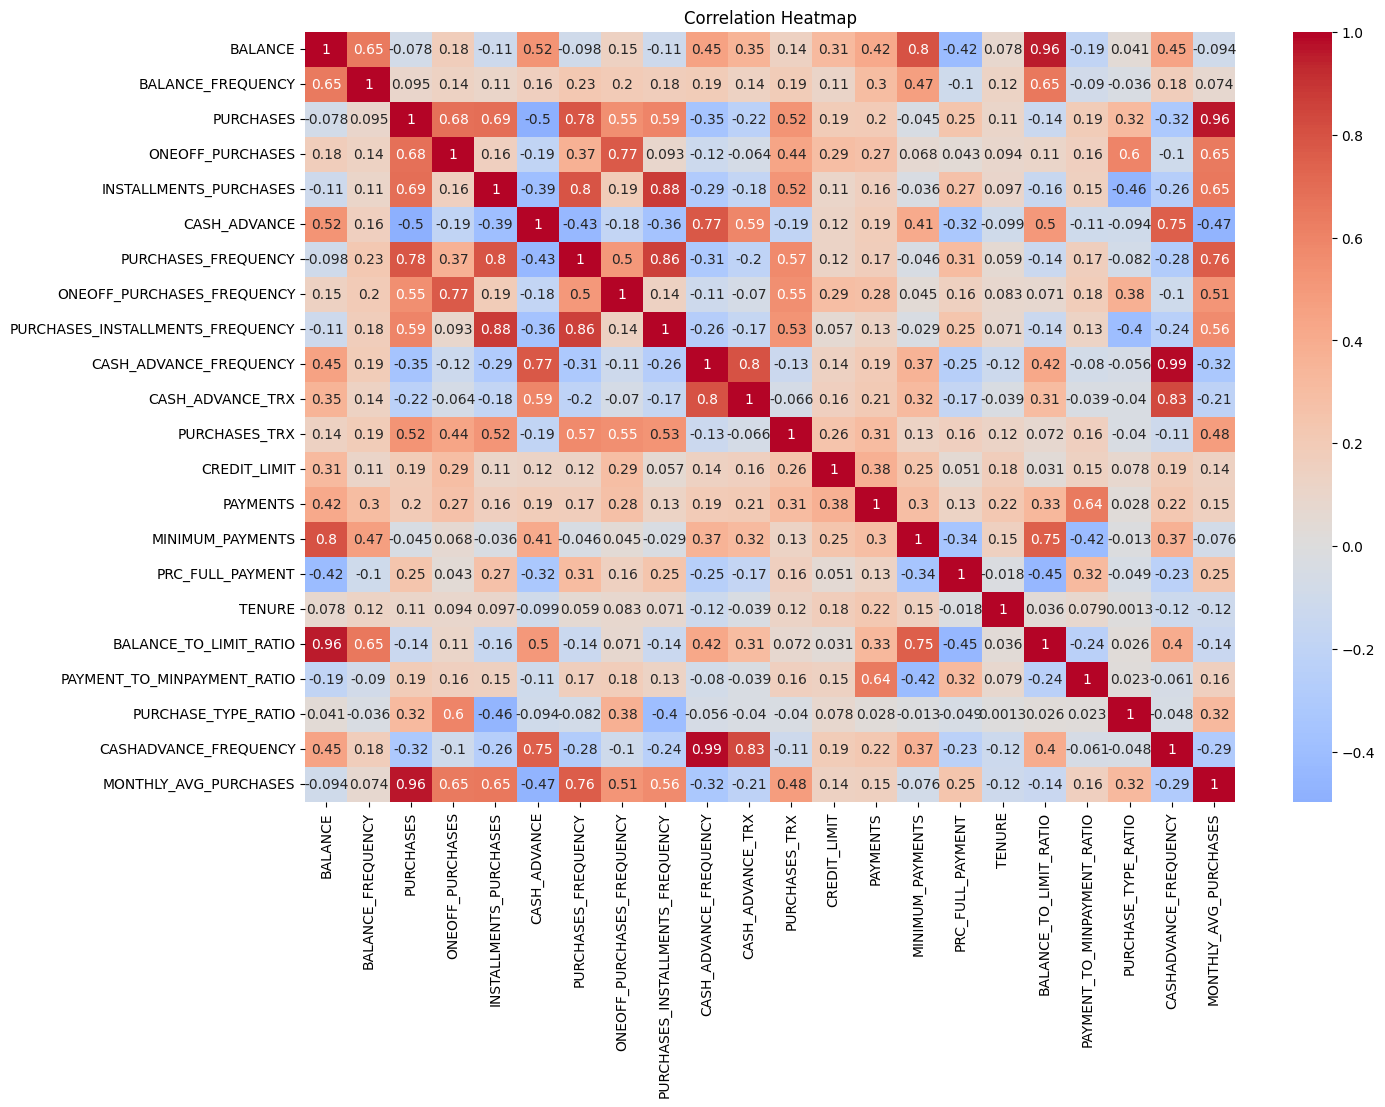

In [19]:
# Create new features that might be insightful
clean_df['BALANCE_TO_LIMIT_RATIO'] = clean_df['BALANCE'] / (clean_df['CREDIT_LIMIT'] + 1)
clean_df['PAYMENT_TO_MINPAYMENT_RATIO'] = clean_df['PAYMENTS'] / (clean_df['MINIMUM_PAYMENTS'] + 1)
clean_df['PURCHASE_TYPE_RATIO'] = clean_df['ONEOFF_PURCHASES'] / (clean_df['INSTALLMENTS_PURCHASES'] + 1)
clean_df['CASHADVANCE_FREQUENCY'] = clean_df['CASH_ADVANCE'] * clean_df['CASH_ADVANCE_FREQUENCY']
clean_df['MONTHLY_AVG_PURCHASES'] = clean_df['PURCHASES'] / (clean_df['TENURE'] + 1)
# Check correlation
plt.figure(figsize=(15, 10))
sns.heatmap(clean_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

## Data Scaling

In [20]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clean_df)
scaled_df = pd.DataFrame(scaled_data, columns=clean_df.columns)

scaled_df.head(1)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,BALANCE_TO_LIMIT_RATIO,PAYMENT_TO_MINPAYMENT_RATIO,PURCHASE_TYPE_RATIO,CASHADVANCE_FREQUENCY,MONTHLY_AVG_PURCHASES
0,-1.226618,-0.2687,-0.116024,-0.988096,0.390807,-0.931958,-0.810075,-0.679802,-0.710406,-0.680728,...,-1.442016,-0.871536,-0.799518,-0.527662,0.359451,-0.986993,-0.320551,-0.639086,-0.62719,-0.180306


## Number of Clusters

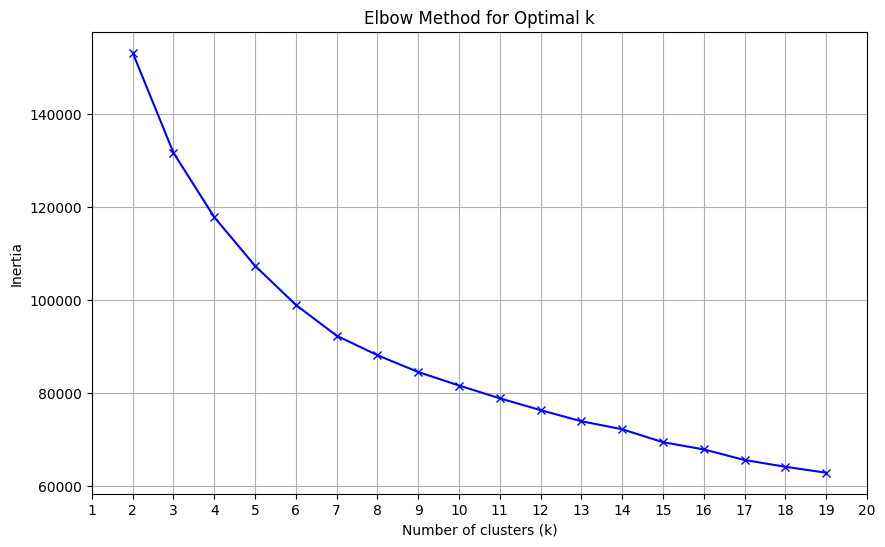

In [21]:
inertia = []
K = range(2, 20)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.title('Elbow Method for Optimal k')
plt.xticks(range(1,21))
plt.show()


## K-Means Clustering

Cluster Distribution:
Cluster
0    2129
1    1487
2    3088
3    2190
Name: count, dtype: int64


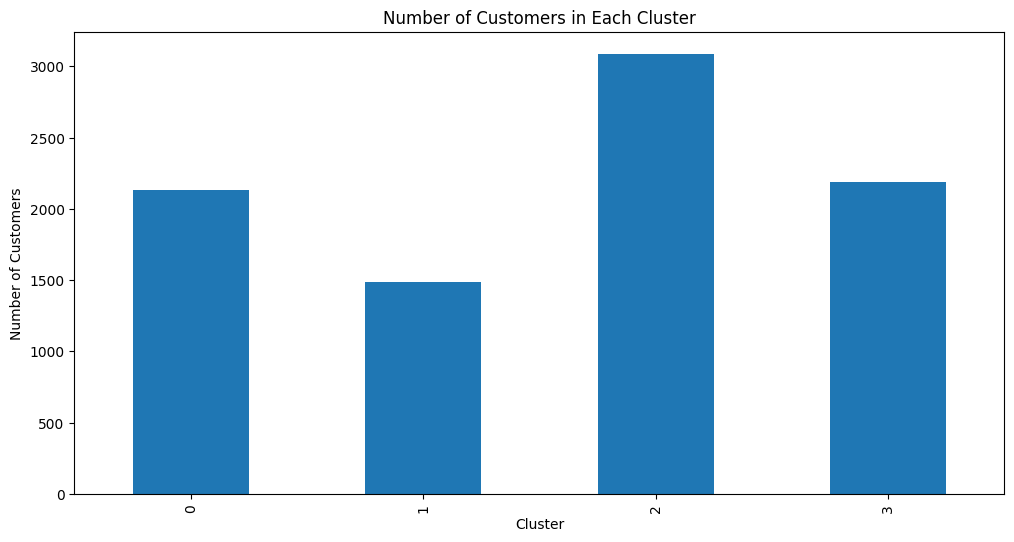

In [26]:
optimal_k = 4  #

# Apply K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_df)

# Add cluster labels to original data
clean_df['Cluster'] = clusters
scaled_df['Cluster'] = clusters

# Analyze cluster sizes
cluster_distribution = clean_df['Cluster'].value_counts().sort_index()
print("Cluster Distribution:")
print(cluster_distribution)

plt.figure(figsize=(12, 6))
cluster_distribution.plot(kind='bar')
plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

## PCA

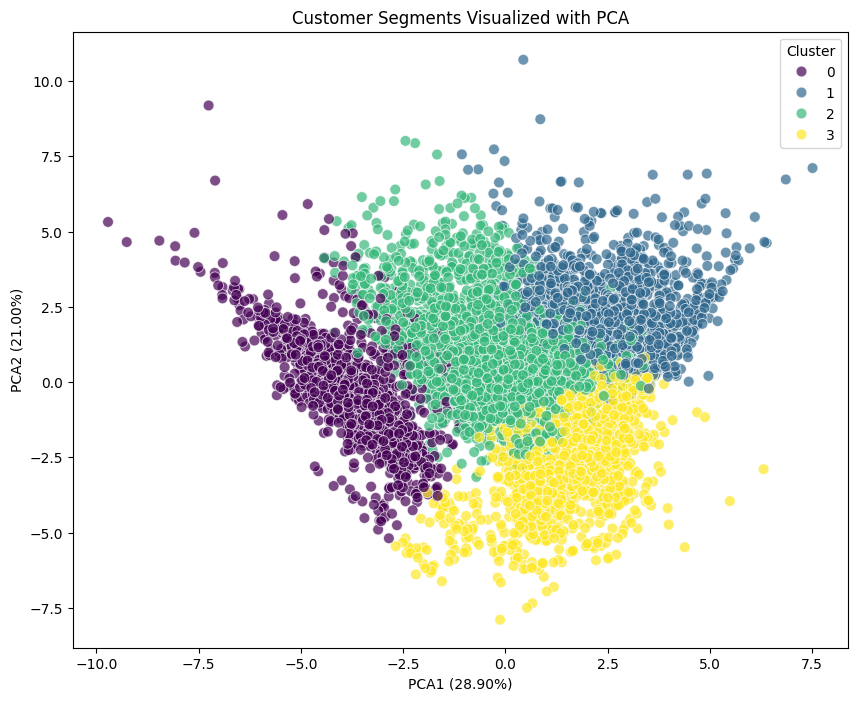

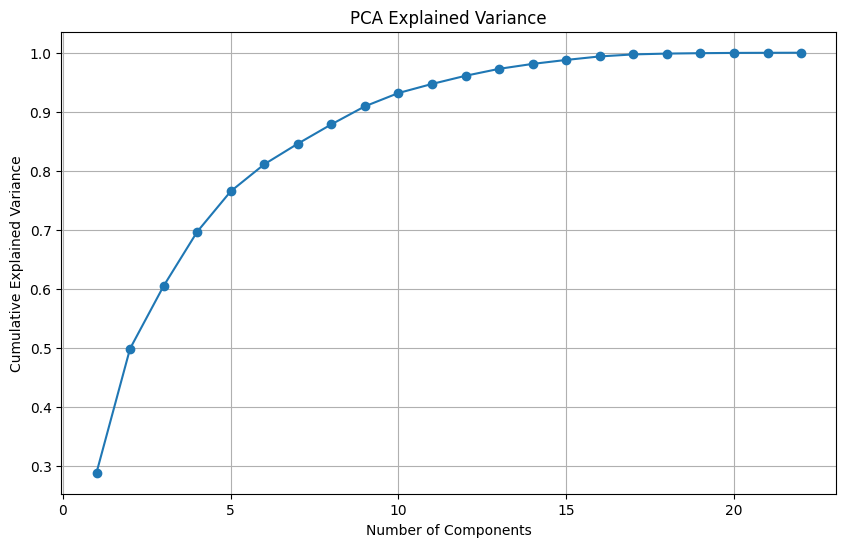

In [27]:
# Apply PCA for 2D visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df.drop('Cluster', axis=1))

# Create DataFrame for PCA results
pca_df = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = clusters

# Visualize clusters in 2D
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df,
                palette='viridis', s=60, alpha=0.7)
plt.title('Customer Segments Visualized with PCA')
plt.xlabel(f'PCA1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PCA2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.legend(title='Cluster')
plt.show()

# Check PCA explained variance
pca_full = PCA()
pca_full.fit(scaled_df.drop('Cluster', axis=1))

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

# Cluster Analysis & Interpretation


Cluster Characteristics (Mean Values):
          BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  \
Cluster                                                              
0        7.288623   0.374566      6.944009      8.026351  6.681044   
1        6.972931   7.860836      1.945803      8.670110  7.747484   
2        6.959210   6.194006      3.544612      8.021724  6.720019   
3        3.466200   5.492801      0.423806      7.853308  5.782322   

         PURCHASES_FREQUENCY  PRC_FULL_PAYMENT  INSTALLMENTS_PURCHASES  
Cluster                                                                 
0                   0.018097          0.032457                0.243901  
1                   0.923565          0.236118                6.616014  
2                   0.525810          0.058685                2.938324  
3                   0.611225          0.353570                4.786342  


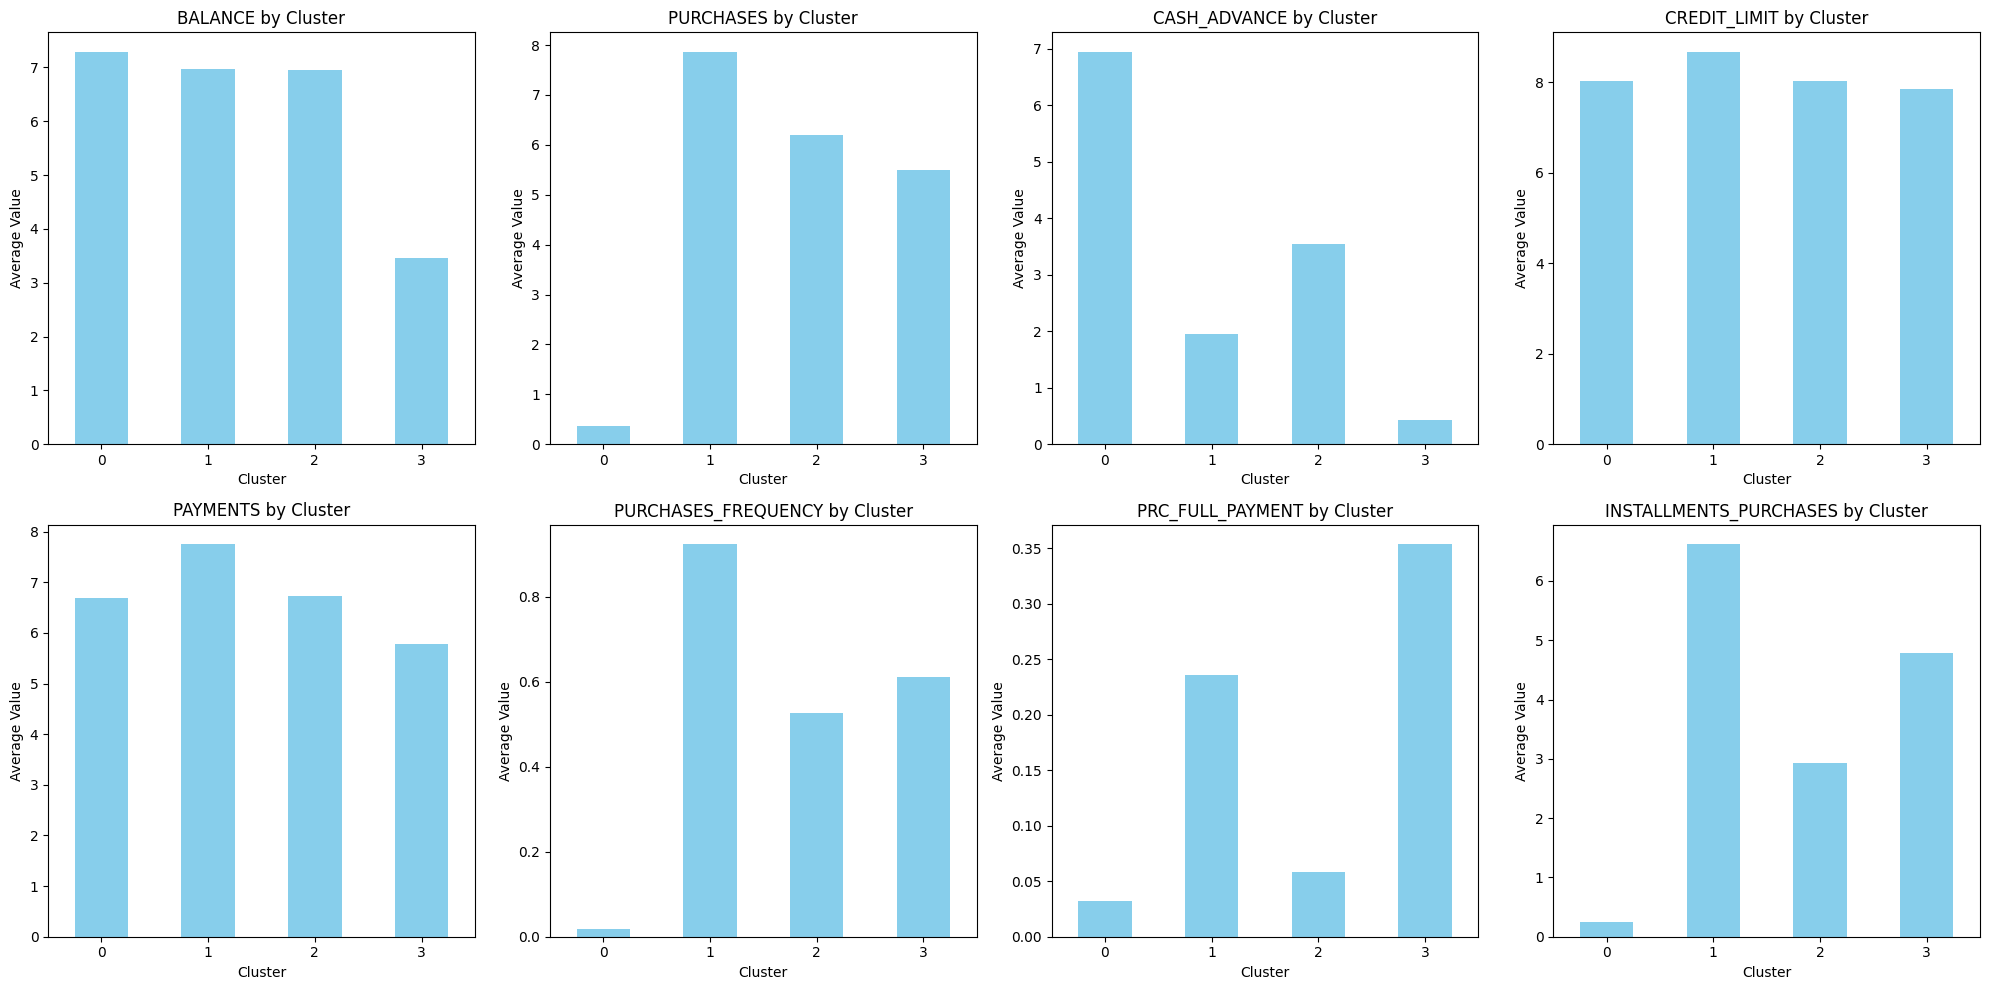

In [28]:
# Analyze cluster characteristics
cluster_summary = clean_df.groupby('Cluster').mean()

# Highlight key metrics for each cluster
key_metrics = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
               'PAYMENTS', 'PURCHASES_FREQUENCY', 'PRC_FULL_PAYMENT','INSTALLMENTS_PURCHASES']

print("\nCluster Characteristics (Mean Values):")
print(cluster_summary[key_metrics])

# Visualize cluster characteristics
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, metric in enumerate(key_metrics[:8]):
    cluster_summary[metric].plot(kind='bar', ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'{metric} by Cluster')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel('Average Value')
    axes[idx].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## Personas

In [30]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [38]:
def assign_persona(cluster_num, row):
    if cluster_num == 0:
        return "Sleeping Giant"
    elif cluster_num == 1:
        return "VIP Spenders"
    elif cluster_num == 2:
        return "Average Joes"
    elif cluster_num == 3:
        return "Responsible Regulars"
    else:
        return "Others"

clean_df['Persona'] = clean_df.apply(lambda x: assign_persona(x['Cluster'], x), axis=1)


clean_df[finance_columns] = clean_df[finance_columns].apply(lambda x: np.expm1(x))


# Summary statistics by persona
persona_summary = clean_df.groupby('Persona').agg({
    'BALANCE': 'mean',
    'PURCHASES': 'mean',
    'CREDIT_LIMIT': 'mean',
    'PURCHASES_FREQUENCY': 'mean',
    'PRC_FULL_PAYMENT': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Count'})

print("\nCustomer Personas Summary:")
print(persona_summary)


Customer Personas Summary:
                          BALANCE    PURCHASES  CREDIT_LIMIT  \
Persona                                                        
Average Joes          1860.182151   837.191626   4217.662473   
Responsible Regulars    72.184751   493.316082   3382.275518   
Sleeping Giant        2328.467119     9.717116   4165.463228   
VIP Spenders          2085.954165  3549.940067   7044.675063   

                      PURCHASES_FREQUENCY  PRC_FULL_PAYMENT  Count  
Persona                                                             
Average Joes                     0.525810          0.058685   3088  
Responsible Regulars             0.611225          0.353570   2190  
Sleeping Giant                   0.018097          0.032457   2129  
VIP Spenders                     0.923565          0.236118   1487  


In [40]:
persona_insights = {
    "Sleeping Giants (Cluster 0)": {
        "Behavior": "High limits, minimal usage, rare full payments",
        "Size": 2129,
        "Revenue Potential": "High (if activated)",
        "Risk": "High (high limits, low usage)",
        "Key Metric": "Credit Limit:	$4,165, Purchases: $10"
    },
    "VIP Spenders (Cluster 1)": {
        "Behavior": "Maximum usage, high spending, moderate full payments",
        "Size": 1487,
        "Revenue Potential": "Very High",
        "Risk": "Medium (high spending, moderate payments)",
        "Key Metric": "Purchases: $3,550 (highest), Frequency: 0.92 (highest)"
    },
    "Average Joes (Cluster 2)": {
        "Behavior": "Average usage, carry balances, minimal full payments",
        "Size": 3088,
        "Revenue Potential": "Steady",
        "Risk": "Medium (consistent behavior)",
        "Key Metric": "Size: 3088 (largest group)"
    },
    "Responsible Regulars (Cluster 3)": {
        "Behavior": "Active usage, manage balances well, better payments",
        "Size": 2190,
        "Revenue Potential": "Growing",
        "Risk": "Low",
        "Key Metric": "Full Payment: 35% (best), Balance: $72 (lowest)"
    }
}

persona_insight = pd.DataFrame(persona_insights)
print(persona_insight)

                                      Sleeping Giants (Cluster 0)  \
Behavior           High limits, minimal usage, rare full payments   
Size                                                         2129   
Revenue Potential                             High (if activated)   
Risk                                High (high limits, low usage)   
Key Metric                  Credit Limit:\t$4,165, Purchases: $10   

                                            VIP Spenders (Cluster 1)  \
Behavior           Maximum usage, high spending, moderate full pa...   
Size                                                            1487   
Revenue Potential                                          Very High   
Risk                       Medium (high spending, moderate payments)   
Key Metric         Purchases: $3,550 (highest), Frequency: 0.92 (...   

                                            Average Joes (Cluster 2)  \
Behavior           Average usage, carry balances, minimal full pa...   
Size    



---

